In [1]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

In [5]:
from scipy.stats import spearmanr

In [ ]:
all_df = pd.read_csv(
    "./Fig.5.value.csv",
    index_col=0,
)


# fig5A

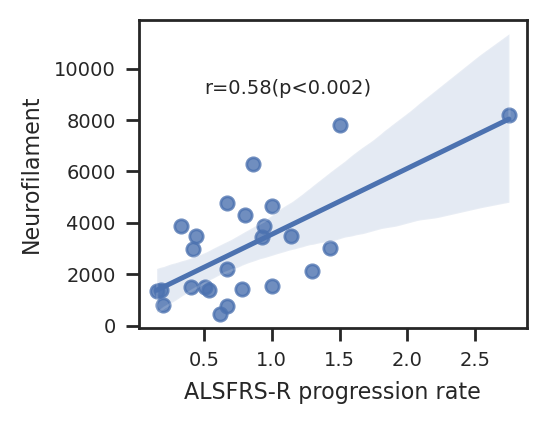

In [77]:
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(2.5, 2))

temp_corr_plot = all_df[["Neurofilament", "ALSFRS-R progressionrate"]].dropna()

r, pvalue = spearmanr(temp_corr_plot)

sns.regplot(temp_corr_plot, y="Neurofilament", x="ALSFRS-R progressionrate", ax=ax)
ax.set_xlabel("ALSFRS-R progression rate", fontsize=8)
ax.set_ylabel("Neurofilament", fontsize=8)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
)
ax.text(
    0.5,
    9000,
    "r=%.2f(p<%.3f)" % (r, pvalue),
    fontsize=7,
)
ax.figure.savefig(
    './Fig.5A.png',
    bbox_inches='tight',
    dpi=700)

/tmp/chaoronc/48232642/ipykernel_3622450/593069757.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: x[0] + "_" + str(x[1]), axis=1)
/tmp/chaoronc/48232642/ipykernel_3622450/593069757.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_corr_plot.min()[0] + 0.07,
/tmp/chaoronc/48232642/ipykernel_3622450/593069757.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_corr_plot.max()[1] * 0.8,


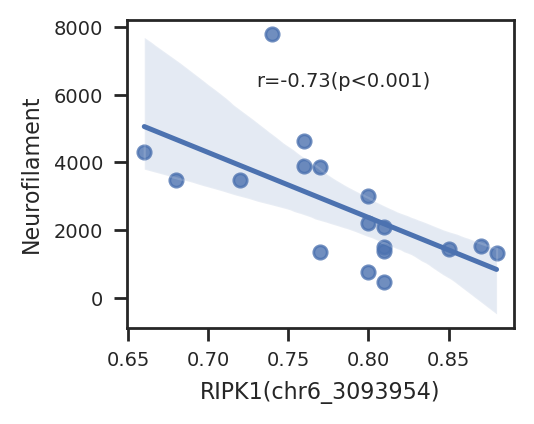

In [26]:
gene = "RIPK1"

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(2.5, 2))

pvalue = [
    "r=%.2f(p<%.3f)" % (x, y)
    for x, y in temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == gene][
        ["NfL_spearmanR", "NfL_spearmanR_p"]
    ].values
][0]

cpg_location = (
    temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == gene]
    .apply(lambda x: x[0] + "_" + str(x[1]), axis=1)
    .values[0]
)

temp_corr_plot = pd.DataFrame(
    [
        temp_merged.loc[cpg_location, nfl_info.id.values].values * 0.01,
        nfl_info["Neurofilament"].values,
    ],
    index=["CpG methyaltion", "Neurofilament"],
).T.dropna()


sns.regplot(data=temp_corr_plot, x="CpG methyaltion", y="Neurofilament", ax=ax)
ax.set_xlabel(f"{gene}({cpg_location})", fontsize=8)
ax.set_ylabel("Neurofilament", fontsize=8)

ax.text(
    temp_corr_plot.min()[0] + 0.07,
    temp_corr_plot.max()[1] * 0.8,
    pvalue,fontsize=7,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
)

ax.figure.savefig(
    './Fig.5B.png',
    bbox_inches='tight',
    dpi=600)

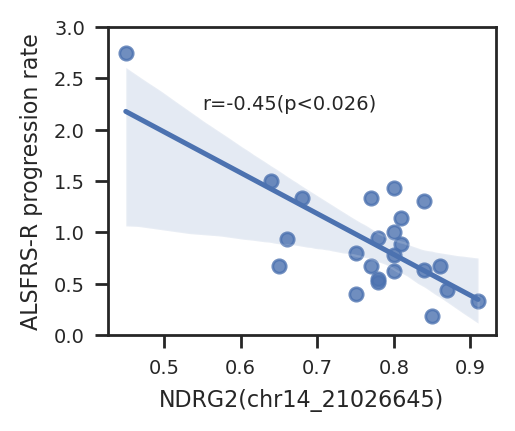

In [39]:
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(2.5, 2))

temp_corr_plot = pd.DataFrame(
    [
        temp_merged.loc["chr14_21026645", ALSFRS_info.id.values].values * 0.01,
        ALSFRS_info["ALSFRS-R progressionrate"].values,
    ],
    index=["CpG methyaltion", "ALSFRS-R progression"],
).T.dropna()
pvalue = [
    "r=%.2f(p<%.3f)" % (x, y)
    for x, y in temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == "NDRG2"][
        ["ALSFRS_spearmanR", "ALSFRS_spearmanR_p"]
    ].values
][0]
sns.regplot(temp_corr_plot, x="CpG methyaltion", y="ALSFRS-R progression", ax=ax)


ax.set_xlabel("NDRG2(chr14_21026645)", fontsize=8)
ax.set_ylabel("ALSFRS-R progression rate", fontsize=8)
ax.text(
    0.55,
    2.2,
    pvalue,
    fontsize=7,
)
ax.set_ylim(0, 3)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
)
ax.figure.savefig("./Fig.5D.png", bbox_inches="tight", dpi=600)

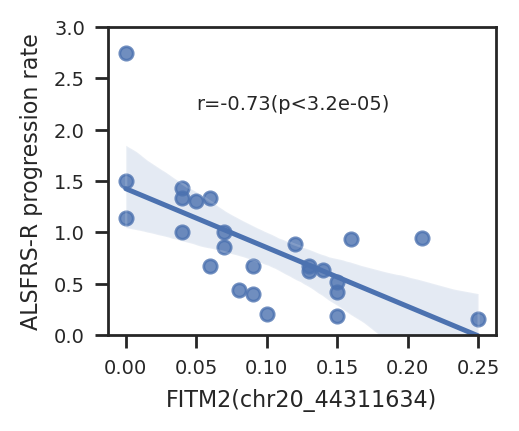

In [38]:
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(2.5, 2))
temp_corr_plot = pd.DataFrame(
    [
        temp_merged.loc["chr20_44311634", ALSFRS_info.id.values].values * 0.01,
        ALSFRS_info["ALSFRS-R progressionrate"].values,
    ],
    index=["CpG methyaltion", "ALSFRS-R progression"],
).T.dropna()
pvalue = [
    "r=%.2f(p<%.1e)" % (x, y)
    for x, y in temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == "FITM2"][
        ["ALSFRS_spearmanR", "ALSFRS_spearmanR_p"]
    ].values
][0]
sns.regplot(temp_corr_plot, x="CpG methyaltion", y="ALSFRS-R progression", ax=ax)

ax.set_xlabel("FITM2(chr20_44311634)", fontsize=8)
ax.set_ylabel("ALSFRS-R progression rate", fontsize=8)

ax.set_ylim(0, 3)

ax.text(
    0.05,
    2.2,
    pvalue,
    fontsize=7,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=7,
)
ax.figure.savefig("./Fig.5E.png", bbox_inches="tight", dpi=600)

/tmp/chaoronc/48232642/ipykernel_3622450/3390590168.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_corr_plot_2.min()[0],
/tmp/chaoronc/48232642/ipykernel_3622450/3390590168.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_corr_plot_2.max()[1] * 0.9,
/tmp/chaoronc/48232642/ipykernel_3622450/3390590168.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_corr_plot_1.min()[0],
/tmp/chaoronc/48232642/ipykernel_3

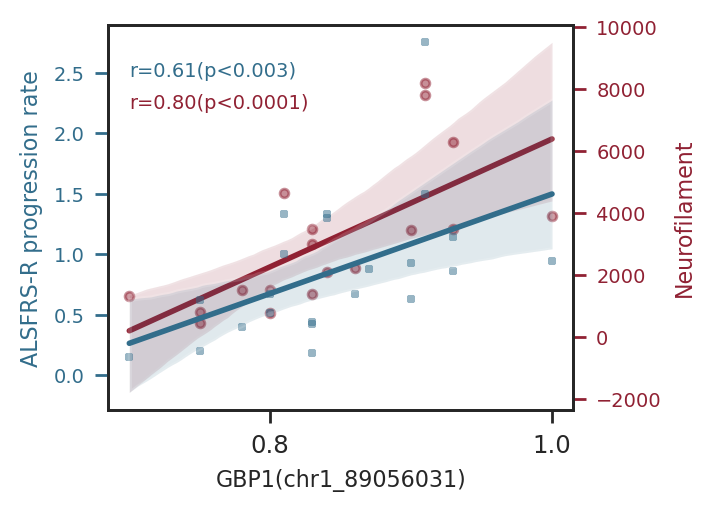

In [59]:
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(3, 2.5))

ax2 = ax.twinx()
sns.set_theme(context="talk", style="ticks")
temp_corr_plot_2 = pd.DataFrame(
    [
        temp_merged.loc["chr1_89056031", nfl_info.id.values].values * 0.01,
        nfl_info["Neurofilament"].values,
    ],
    index=["CpG methyaltion", "Neurofilament"],
).T.dropna()
pvalue_2 = [
    "r=%.2f(p<%.4f)" % (x, y)
    for x, y in temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == "GBP1"][
        ["NfL_spearmanR", "NfL_spearmanR_p"]
    ].values
][0]
sns.regplot(
    temp_corr_plot_2,
    x="CpG methyaltion",
    y="Neurofilament",
    ax=ax,
    color="#902133",
    scatter_kws={"alpha": 0.5, "s": 10},
    line_kws={
        "linewidth": 2,
    },  # Set the color and style of the regression line
)
ax.set_xlabel("GBP1(chr1_89056031)", fontsize=8)
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
ax.tick_params(axis="y", colors="#902133", labelsize=7)
ax.yaxis.label.set_color("#902133")
ax.set_ylabel("Neurofilament", fontsize=8)

ax.text(
    temp_corr_plot_2.min()[0],
    temp_corr_plot_2.max()[1] * 0.9,
    pvalue_2,
    color="#902133",
    fontsize=7,
)

temp_corr_plot_1 = pd.DataFrame(
    [
        temp_merged.loc["chr1_89056031", ALSFRS_info.id.values].values * 0.01,
        ALSFRS_info["ALSFRS-R progressionrate"].values,
    ],
    index=["CpG methyaltion", "ALSFRS-R progression"],
).T.dropna()


pvalue_1 = [
    "r=%.2f(p<%.3f)" % (x, y)
    for x, y in temp_cpg4annoted_[temp_cpg4annoted_["annot.symbol"] == "GBP1"][
        ["ALSFRS_spearmanR", "ALSFRS_spearmanR_p"]
    ].values
][0]

sns.regplot(
    temp_corr_plot_1,
    x="CpG methyaltion",
    y="ALSFRS-R progression",
    ax=ax2,
    color="#326D8B",
    marker="+",
    scatter_kws={"alpha": 0.5, "s": 10},
    line_kws={
        "linewidth": 2,
    },  # Set the color and style of the regression line
)
ax2.yaxis.set_label_position("left")
ax2.yaxis.set_ticks_position("left")
ax2.tick_params(axis="y", colors="#326D8B", labelsize=7)
ax2.yaxis.label.set_color("#326D8B")
ax2.set_ylabel("ALSFRS-R progression rate", fontsize=8)

ax2.text(
    temp_corr_plot_1.min()[0],
    temp_corr_plot_1.max()[1] * 0.9,
    pvalue_1,
    color="#326D8B",
    fontsize=7,
)
ax.figure.savefig("./Fig.5C.png", bbox_inches="tight", dpi=600)

In [80]:
pd.concat(
    [
        ALSFRS_info.set_index("id", drop=True)[
            ["Neurofilament", "ALSFRS-R progressionrate"]
        ],
        temp_merged.loc[
            ["chr14_21026645", "chr20_44311634", "chr1_89056031", "chr1_89056031"],
            ALSFRS_info.id.values,
        ].T/100,
    ],
    axis=1,
).sort_values(
    by="ALSFRS-R progressionrate"
)



,Neurofilament,ALSFRS-R progressionrate,chr14_21026645,chr20_44311634,chr1_89056031,chr1_89056031
sALS_36,1324.0,0.15,NaN,0.25,0.70,0.70
sALS_39,1385.0,0.18,0.85,0.15,0.83,0.83
sALS_25,807.0,0.20,NaN,0.10,0.75,0.75
sALS_26,3864.0,0.33,0.91,NaN,NaN,NaN
C9-Patient_74,1497.0,0.40,0.75,0.09,0.78,0.78
sALS_30,2997.0,0.42,NaN,0.15,0.83,0.83
C9-Patient_69,3468.0,0.44,0.87,0.08,0.83,0.83
sALS_33,1518.0,0.51,0.78,0.15,0.80,0.80
sALS_22,1365.0,0.54,0.78,NaN,NaN,NaN
C9-Patient_67,455.0,0.62,0.80,0.13,0.75,0.75


In [79]:
pd.concat(
    [
        ALSFRS_info.set_index("id", drop=True)[
            ["Neurofilament", "ALSFRS-R progressionrate"]
        ],
        temp_merged.loc[
            ["chr14_21026645", "chr20_44311634", "chr1_89056031", "chr1_89056031"],
            ALSFRS_info.id.values,
        ].T
        / 100,
    ],
    axis=1,
).to_csv("./Fig.5.value.csv")